 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - XOR Gate

In [1]:
import numpy as np
from tensorflow import keras

xor_x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
xor_y = np.array([[0], [1], [1], [0]], dtype=np.float32)

xor_model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')
])

xor_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

xor_history = xor_model.fit(xor_x, xor_y, epochs=500, verbose=0)
xor_predictions = (xor_model.predict(xor_x, verbose=0) > 0.5).astype(int)

print('XOR accuracy:', xor_history.history['accuracy'][-1])
print(np.hstack([xor_x.astype(int), xor_y.astype(int), xor_predictions]))

XOR accuracy: 1.0
[[0 0 0 0]
 [0 1 1 1]
 [1 0 1 1]
 [1 1 0 0]]


## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

![mnist_data_sample.png](attachment:eb3e0d6a-ccb0-499d-9847-ecbc554dbce0.png)

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [2]:
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.random.seed(42)
keras.utils.set_random_seed(42)

font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


#### 1.2 Dataset examination

Using the following code, display random images,

In [5]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.arange(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

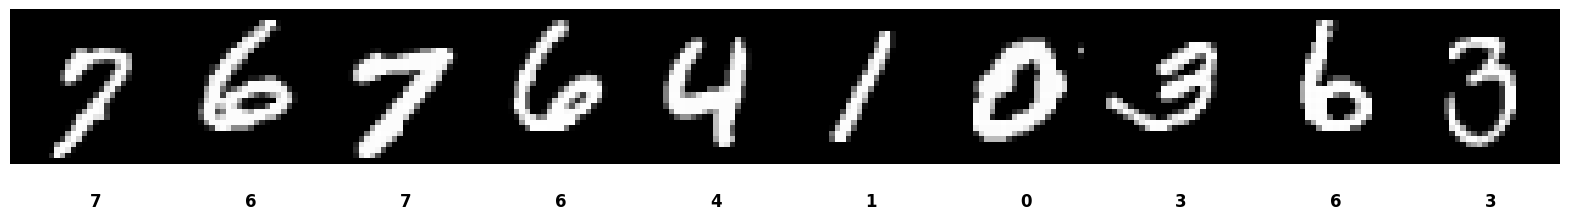

In [8]:
display_random_images(X_train, y_train)

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

In [9]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

num_classes = len(np.unique(y_train))
y_train_encoded = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_encoded = keras.utils.to_categorical(y_test, num_classes=num_classes)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)
print('Encoded labels shape:', y_train_encoded.shape)

Training set shape: (60000, 28, 28, 1)
Testing set shape: (10000, 28, 28, 1)
Encoded labels shape: (60000, 10)


### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [10]:
model = Sequential()
model.add(keras.layers.Input(shape=(28, 28, 1)))
model.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(num_classes, activation='softmax'))


#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem

In [11]:
learning_rate = 0.001
loss = 'categorical_crossentropy'
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
metrics = ['accuracy']

model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [12]:
epochs = 10
batch_size = 128

history = model.fit(
    X_train,
    y_train_encoded,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.8939 - loss: 0.3894 - val_accuracy: 0.9533 - val_loss: 0.1693
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9606 - loss: 0.1420 - val_accuracy: 0.9721 - val_loss: 0.1059
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9725 - loss: 0.0971 - val_accuracy: 0.9768 - val_loss: 0.0846
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9785 - loss: 0.0771 - val_accuracy: 0.9794 - val_loss: 0.0752
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9815 - loss: 0.0656 - val_accuracy: 0.9805 - val_loss: 0.0701
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9838 - loss: 0.0576 - val_accuracy: 0.9810 - val_loss: 0.0671
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9852 - loss: 0.0516 - val_accuracy: 0.9815 - val_loss: 0.0652
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9871 - loss: 0.0467 - 

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

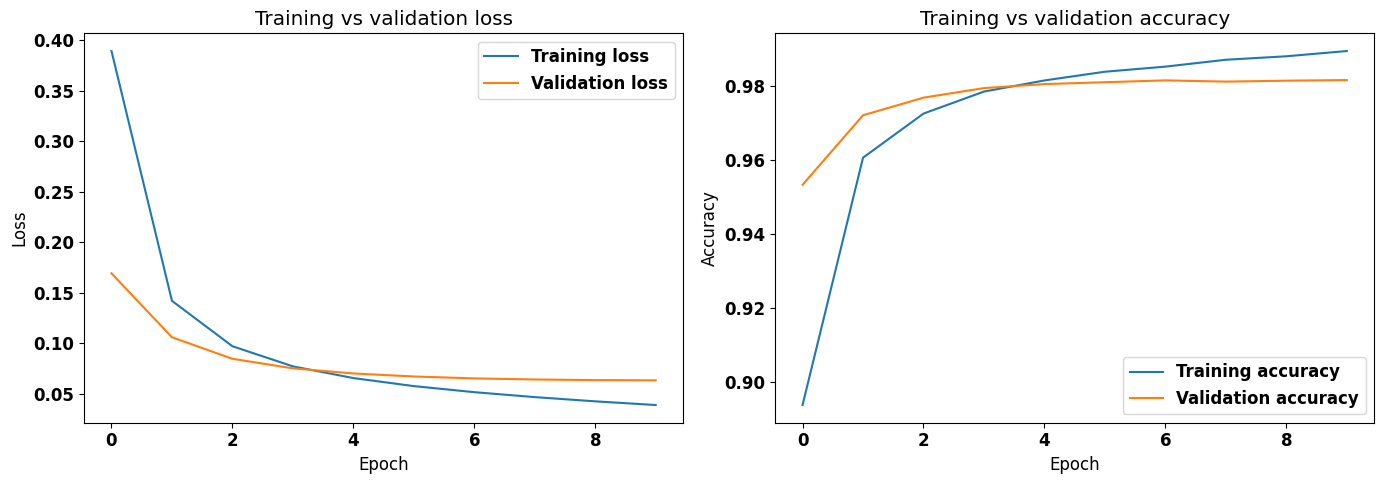

In [13]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs validation loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs validation accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

Test loss: 0.0559
Test accuracy: 0.9813


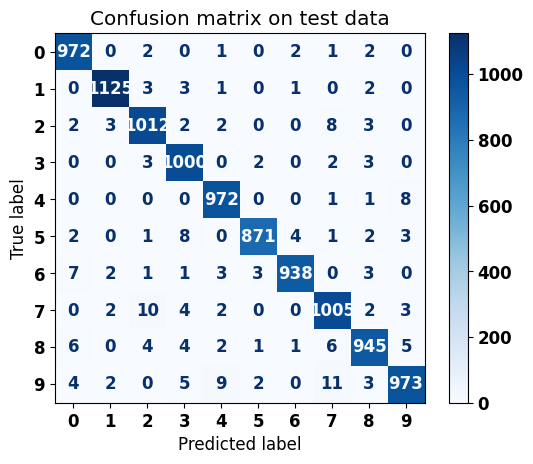

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.97      0.98      0.97      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix on test data')
plt.show()

print(classification_report(y_test, y_pred))

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it

### Question 5: Hyperparameter Tuning and Regularization Techniques

Let's try modifying the model by adding a Dropout layer and adjusting the learning rate.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)


Training the tuned model...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step - accuracy: 0.8602 - loss: 0.5559 - val_accuracy: 0.9280 - val_loss: 0.2592
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9298 - loss: 0.2414 - val_accuracy: 0.9497 - val_loss: 0.1818
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9484 - loss: 0.1766 - val_accuracy: 0.9628 - val_loss: 0.1380
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9603 - loss: 0.1396 - val_accuracy: 0.9708 - val_loss: 0.1132
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9660 - loss: 0.1183 - val_accuracy: 0.9736 - val_loss: 0.1001
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.9695 - loss: 0.1045 - val_accuracy: 0.9759 - val_loss: 0.0891
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9725 - loss: 0.0949 - val_accuracy: 0.9770 - val_loss: 0.0831
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accur

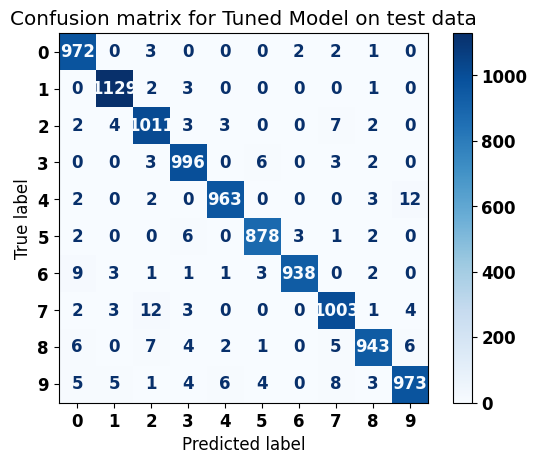

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.97      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


--- Analysis of changes ---
By adding a Dropout layer and potentially adjusting the learning rate, we aim to prevent overfitting. 
Comparing the validation loss and accuracy plots between the original and tuned models can help identify if o

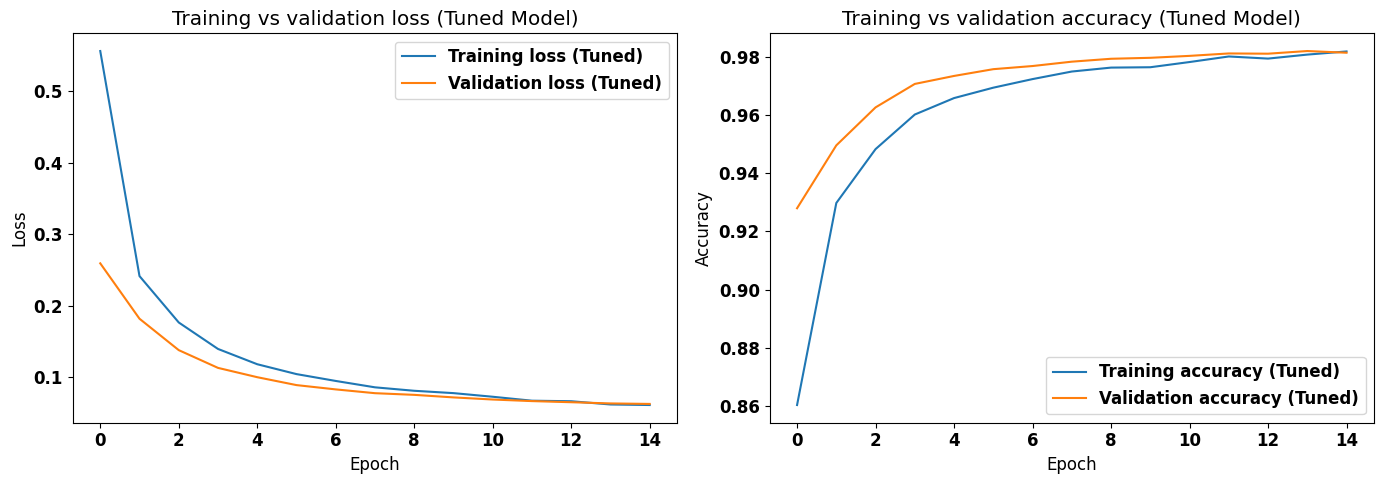

In [15]:
print("### Question 5: Hyperparameter Tuning and Regularization Techniques")
print("\nLet's try modifying the model by adding a Dropout layer and adjusting the learning rate.")

# Define a new model with a Dropout layer
model_tuned = Sequential()
model_tuned.add(keras.layers.Input(shape=(28, 28, 1)))
model_tuned.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'))
model_tuned.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model_tuned.add(keras.layers.Dropout(0.25)) # Added Dropout layer
model_tuned.add(keras.layers.Flatten())
model_tuned.add(keras.layers.Dense(num_classes, activation='softmax'))

# Compile the tuned model with a slightly different learning rate
learning_rate_tuned = 0.0005 # Reduced learning rate
optimizer_tuned = keras.optimizers.Adam(learning_rate=learning_rate_tuned)

model_tuned.compile(loss=loss, optimizer=optimizer_tuned, metrics=metrics)
model_tuned.summary()

print("\nTraining the tuned model...")
# Train the tuned model
history_tuned = model_tuned.fit(
    X_train,
    y_train_encoded,
    epochs=15, # Increased epochs
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

print("\nEvaluating the tuned model...")
# Evaluate the tuned model on the test set
test_loss_tuned, test_accuracy_tuned = model_tuned.evaluate(X_test, y_test_encoded, verbose=0)
print(f'Tuned Model Test loss: {test_loss_tuned:.4f}')
print(f'Tuned Model Test accuracy: {test_accuracy_tuned:.4f}')

y_pred_prob_tuned = model_tuned.predict(X_test, verbose=0)
y_pred_tuned = np.argmax(y_pred_prob_tuned, axis=1)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned)
disp_tuned.plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix for Tuned Model on test data')
plt.show()

print(classification_report(y_test, y_pred_tuned))

print("\n--- Analysis of changes ---")
print("By adding a Dropout layer and potentially adjusting the learning rate, we aim to prevent overfitting. \nComparing the validation loss and accuracy plots between the original and tuned models can help identify if overfitting was reduced.")

# Plotting training history for the tuned model
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_tuned.history['loss'], label='Training loss (Tuned)')
plt.plot(history_tuned.history['val_loss'], label='Validation loss (Tuned)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs validation loss (Tuned Model)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tuned.history['accuracy'], label='Training accuracy (Tuned)')
plt.plot(history_tuned.history['val_accuracy'], label='Validation accuracy (Tuned)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs validation accuracy (Tuned Model)')
plt.legend()

plt.tight_layout()
plt.show()